In [1]:
# add local src to path for imports
import sys
from pathlib import Path

REPO = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
sys.path.insert(0, str(REPO))
sys.path.insert(0, str(REPO / 'src'))

In [2]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

from utils.io_utils import load
from utils.viz import preview


# 0 Plot Functions

In [3]:
CMAP = 'bwr_r'  # red = negative, white = 0, blue = positive
HALF = LinearSegmentedColormap.from_list('bwr_r_hi', plt.get_cmap(CMAP)(np.linspace(0.5, 1.0, 256)))
PHASES = ['raw', 'unwrapped', 'trig']

def load_fft(df, sample_id=None, position_id=None, speaker=None):
    if sample_id is not None:
        row = df[df['sample_id'] == sample_id].iloc[0]
    else:
        row = df[(df['position_id'] == position_id) & (df['speaker'] == speaker)].iloc[0]
    with np.load(row['raw_fft_path']) as z:
        fft, freqs = z['fft'], z['freqs']  # (1, L, F, C), (F,)
    return fft[0], freqs, row['sample_id']  # (L, F, C)

def select_fft(fft, laser_idx=55, xy_idx=0):
    # compute |FFT|
    if len(fft.shape) == 3: # multiple lasers, both xy
        fft = fft[..., xy_idx]
        assert laser_idx in ['all', 'avg'] + list(range(fft.shape[0])), f'laser_idx must be one of ["all", "avg"] + [0, ..., {fft.shape[0]-1}]'
        fft = fft if laser_idx == 'all' else fft.mean(0) if laser_idx == 'avg' else fft[laser_idx]
    else:
        laser_idx, xy_idx = None, None
    return fft, laser_idx, xy_idx

def plot_shift(shift, sample_id=None, laser_idx=55, xy_idx=0, ax=None, title=None, label=None):
    if ax is None: fig, ax = plt.subplots(figsize=(16, 4))

    title = (title + " " if title is not None else "") + "Shift"
    if sample_id is not None: title += f' {sample_id}'
    ax.set_title(title)

    if label is None:
        label = f'{laser_idx}lr' if laser_idx is not None else ''
        if xy_idx is not None: label += f'  {"xy"[xy_idx]}'
        if sample_id is not None: label += f' ({sample_id})'

    if laser_idx == 'all': # plot heatmap
        im = ax.imshow(shift, aspect='auto', origin='lower', cmap=CMAP, vmin=-1, vmax=1, extent=[0, shift.shape[1], 0, len(shift)])
        ax.set_ylabel('Laser')
        ax.set_xlabel('Frequency (Hz)')
        ax.figure.colorbar(im, ax=ax, label=r'$\Delta$ [m]')
    else:
        ax.plot(shift)
        ax.set_ylabel(r'$\Delta$ [m]')
        ax.set_xlabel('Frequency (Hz)')
        ax.set_xlim(0, shift.shape[0])
    if shift.ndim != 3: # (100 lasers, 2500 frames, 2 xy)
        xy_idx, laser_idx = None, None

    if label is not None: ax.legend()
    # return ax

# def compute_fft(signal, fs, min_freq, max_freq, *, **kwargs):
#     fft = np.fft.rfft(signal).astype(np.complex64)
#     freqs = np.fft.rfftfreq(len(signal), d=1.0 / fs)
#     # rfft returns freqs from 0 to fs/2 (up until Nyquist), so we mask out all unused freqs
#     mask = (freqs >= min_freq) & (freqs <= max_freq)
#     fft, freqs = fft[..., mask], freqs[mask]
#     return fft, freqs

# def compute_mag(fft, *, **kwargs): return np.abs(fft)
# def compute_phase(fft, *, **kwargs): return np.angle(fft)

def plot_mag(fft, freqs, sample_id=None, laser_idx=55, xy_idx=0, ax=None, log=True, title=None, label=None):
    if ax is None: fig, ax = plt.subplots(figsize=(16, 4))

    # compute |FFT|
    fft, laser_idx, xy_idx = select_fft(fft, laser_idx=laser_idx, xy_idx=xy_idx)
    mag = np.abs(fft)

    if log: mag = np.log(mag)

    title = (title + " " if title is not None else "") + "FFT Magnitude"
    if sample_id is not None: title += f' {sample_id}'
    ax.set_title(title)

    if label is None:
        label = f'{laser_idx}lr' if laser_idx is not None else ''
        if xy_idx is not None: label += f'  {"xy"[xy_idx]}'
        if sample_id is not None: label += f' ({sample_id})'

    if laser_idx == 'all': # plot as heatmap
        im = ax.imshow(mag, aspect='auto', origin='lower', cmap='Blues', vmin=0, vmax=mag.max(), extent=[freqs[0], freqs[-1], 0, len(mag)])
        ax.set_ylabel('Laser')
        ax.set_xlabel('Frequency (Hz)')
        ax.figure.colorbar(im, ax=ax, label=label)
    else:
        ax.plot(freqs, mag, label=label)
        ax.set_ylabel(label)
        ax.set_xlabel('Frequency (Hz)')
        ax.set_xlim(freqs[0], freqs[-1])

    if label is not None: ax.legend()
    # return ax

def plot_phase(fft, freqs, sample_id=None, laser_idx=55, xy_idx=0, mode='trig', ax=None, title=None, label=None):
    if ax is None: fig, ax = plt.subplots(figsize=(16, 4))

    # compute phase(FFT)
    fft, laser_idx, xy_idx = select_fft(fft, laser_idx=laser_idx, xy_idx=xy_idx)
    phase = np.angle(fft)

    title = (title + " " if title is not None else "") + "FFT Phase"
    if sample_id is not None: title += f' {sample_id}'
    ax.set_title(title)

    if label is None:
        label = f'{laser_idx}lr' if laser_idx is not None else ''
        if xy_idx is not None: label += f'  {"xy"[xy_idx]}'
        if sample_id is not None: label += f' ({sample_id})'

    # select mode
    if mode == 'raw':
        phase, ylabel, vlim = phase, r'$\theta$ [rad]', (-np.pi, np.pi)
    elif mode == 'unwrapped':
        phase, ylabel, vlim = np.unwrap(phase, axis=-1), r'unwrapped $\theta$ [rad]', None
    elif mode == 'trig': # only use cos, not sin
        phase, ylabel, vlim = np.cos(phase), r'$\cos\theta$', (-1, 1)
    else:
        raise ValueError(f'Unknown mode: {mode}. Must be one of {PHASES}')
    if vlim is None: vlim = (phase.min(), phase.max())

    if laser_idx == 'all': # plot heatmap
        im = ax.imshow(phase, aspect='auto', origin='lower', cmap=CMAP, vmin=vlim[0], vmax=vlim[1], extent=[freqs[0], freqs[-1], 0, len(phase)])
        ax.set_ylabel('Laser')
        ax.set_xlabel('Frequency (Hz)')
        ax.figure.colorbar(im, ax=ax, label=ylabel)
    else:
        ax.plot(freqs, phase, label=label)
        ax.set_ylim(vlim[0] * 1.1, vlim[1] * 1.1)
        ax.set_ylabel(ylabel)
        ax.set_xlabel('Frequency (Hz)')
        ax.set_xlim(freqs[0], freqs[-1])

    if label is not None: ax.legend()

    # return ax

# 1 Original Audio

In [4]:
AUDIO_PATH = '/home/ethantu/workspace/good-vibrations/data/audio/chirp_50_1000_1.0sec/audio.wav'

In [5]:
audio, fs = load(AUDIO_PATH)
audio.shape, fs

((52920,), 44100)

In [6]:
preview((audio, fs), 'audio')

/tmp/ipykernel_752951/632851185.py:49: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  if label is not None: ax.legend()


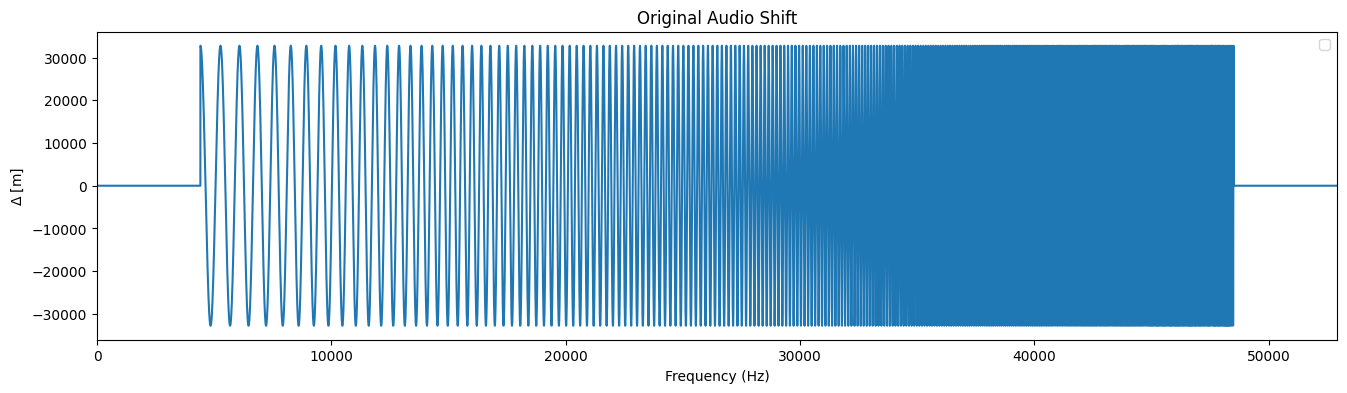

In [7]:
plot_shift(audio, title='Original Audio')

In [8]:
# compute fft, freqs
fft = np.fft.rfft(audio).astype(np.complex64)
freqs = np.fft.rfftfreq(len(audio), d=1.0 / fs)
# rfft returns freqs from 0 to fs/2 (up until Nyquist), so we mask out all unused freqs
mask = (freqs >= 50) & (freqs <= 1000)
fft, freqs = fft[..., mask], freqs[mask]

fft.shape, freqs.shape

((1141,), (1141,))

/tmp/ipykernel_752951/632851185.py:92: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  if label is not None: ax.legend()
/tmp/ipykernel_752951/632851185.py:134: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  if label is not None: ax.legend()


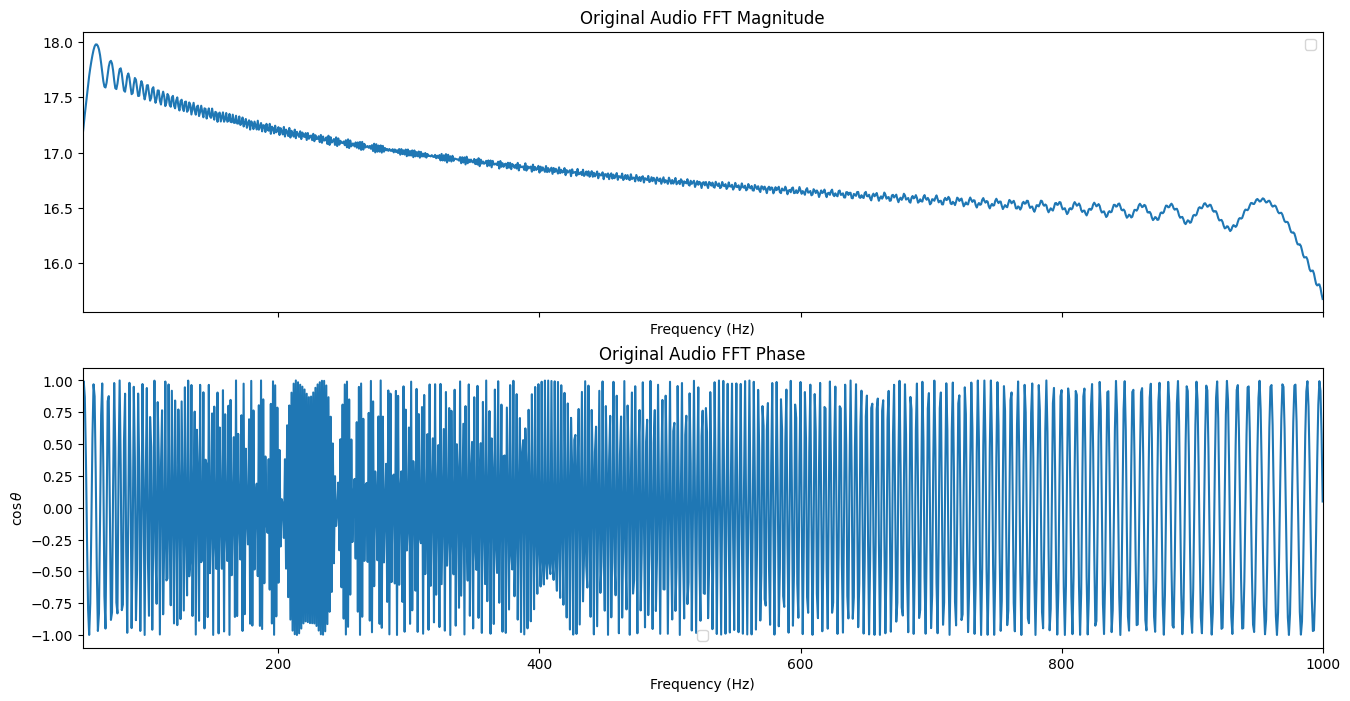

In [9]:
fig, ax = plt.subplots(2, 1, figsize=(16, 8), sharex=True)

plot_mag(fft, freqs, ax=ax[0], title='Original Audio')
plot_phase(fft, freqs, ax=ax[1], title='Original Audio')

# ax[0].set_xlim(100, 150)
# ax[1].set_xlim(100, 150)

# 2 Load the gastronorm dataset

In [10]:
REPO = Path('/home/ethantu/workspace/good-vibrations')
EXP = REPO / 'experiments/31_07_2026_gastronorm_exp1'

RAW_FFT_REL = 'vibration/04_fft.npz'                 # complex64, (1, L, F, C)
RAW_SHIFTS_REL = 'vibration/02_raw_shifts.npy'       # float32,  (L, T, C)     <- plot_shifts wants this
CLEAN_SHIFTS_REL = 'vibration/03_clean_shifts.npy'   # float64,  (1, L, T, C)

In [11]:
def load_gastronorm(exp_dir: Path = EXP, mds_dir: Path | None = None) -> pd.DataFrame:
    """Return one row per sample in the MDS index, with paths to the raw artifacts."""
    if mds_dir is None:
        mds_dir = sorted(exp_dir.glob('mds/*/metadata.jsonl'))[0].parent
    index = [json.loads(l) for l in (mds_dir / 'metadata.jsonl').read_text().strip().splitlines() if l]
    df = pd.DataFrame(index)

    samples = exp_dir / 'samples'
    df['sample_dir'] = df['sample_id'].map(lambda s: samples / s)
    for col, rel in [('raw_fft_path', RAW_FFT_REL),
                     ('raw_shifts_path', RAW_SHIFTS_REL),
                     ('clean_shifts_path', CLEAN_SHIFTS_REL)]:
        df[col] = df['sample_dir'].map(lambda d, rel=rel: d / rel)
        df[col.replace('_path', '_exists')] = df[col].map(lambda p: p.exists())
        df['sample_id'] = df['sample_id'].astype(int)
        df['position_id'] = df['position_id'].astype(int)
        df['speaker'] = df['speaker'].astype(int)

    return df

df = load_gastronorm()
print(f'{len(df)} rows x {df.shape[1]} cols')
df[['sample_id', 'layout', 'speaker', 'position_id', 'n_objects', 'avg_com', 'raw_fft_path', 'raw_shifts_path']].head(8)

3007 rows x 44 cols


,sample_id,layout,speaker,position_id,n_objects,avg_com,raw_fft_path,raw_shifts_path
0,10,empty-box,2,2,0,[-1 -1],/home/ethantu/workspace/good-vibrations/experi...,/home/ethantu/workspace/good-vibrations/experi...
1,11,empty-box,3,2,0,[-1 -1],/home/ethantu/workspace/good-vibrations/experi...,/home/ethantu/workspace/good-vibrations/experi...
2,12,empty-box,4,2,0,[-1 -1],/home/ethantu/workspace/good-vibrations/experi...,/home/ethantu/workspace/good-vibrations/experi...
3,13,empty-box,5,2,0,[-1 -1],/home/ethantu/workspace/good-vibrations/experi...,/home/ethantu/workspace/good-vibrations/experi...
4,14,empty-box,6,2,0,[-1 -1],/home/ethantu/workspace/good-vibrations/experi...,/home/ethantu/workspace/good-vibrations/experi...
5,15,empty-box,7,2,0,[-1 -1],/home/ethantu/workspace/good-vibrations/experi...,/home/ethantu/workspace/good-vibrations/experi...
6,16,empty-box,8,2,0,[-1 -1],/home/ethantu/workspace/good-vibrations/experi...,/home/ethantu/workspace/good-vibrations/experi...
7,17,empty-box,1,3,0,[-1 -1],/home/ethantu/workspace/good-vibrations/experi...,/home/ethantu/workspace/good-vibrations/experi...


# 3 Inspect Recovered FFTs

In [12]:
sample_id = 500
laser_idx = 'all'

fft, freqs, sample_id = load_fft(df, sample_id)
fft.shape, freqs.shape

((100, 1235, 2), (1235,))

/tmp/ipykernel_752951/632851185.py:92: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  if label is not None: ax.legend()
/tmp/ipykernel_752951/632851185.py:134: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  if label is not None: ax.legend()


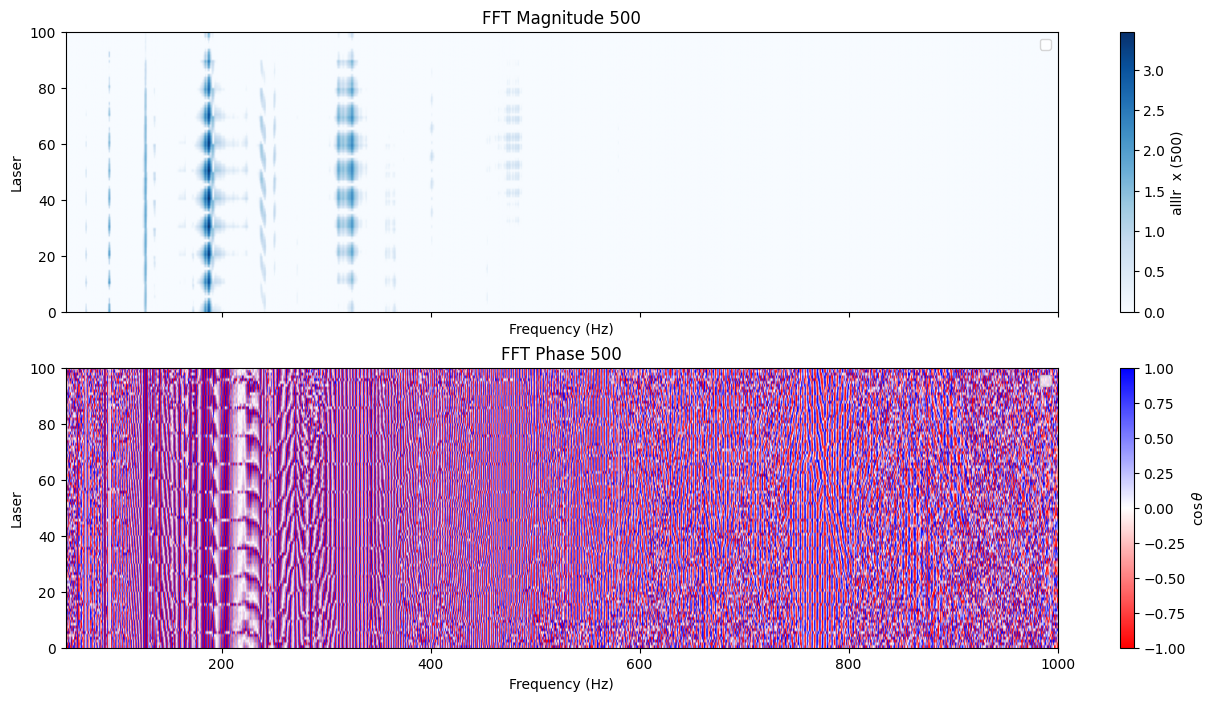

In [13]:
fig, axs = plt.subplots(2, 1, figsize=(16, 8), sharex=True)
plot_mag(fft, freqs, sample_id, xy_idx=0, laser_idx=laser_idx, ax=axs[0])
plot_phase(fft, freqs, sample_id, xy_idx=0, laser_idx=laser_idx, ax=axs[1])

# axs[0].set_xlim(100, 150)
# axs[1].set_xlim(100, 150)

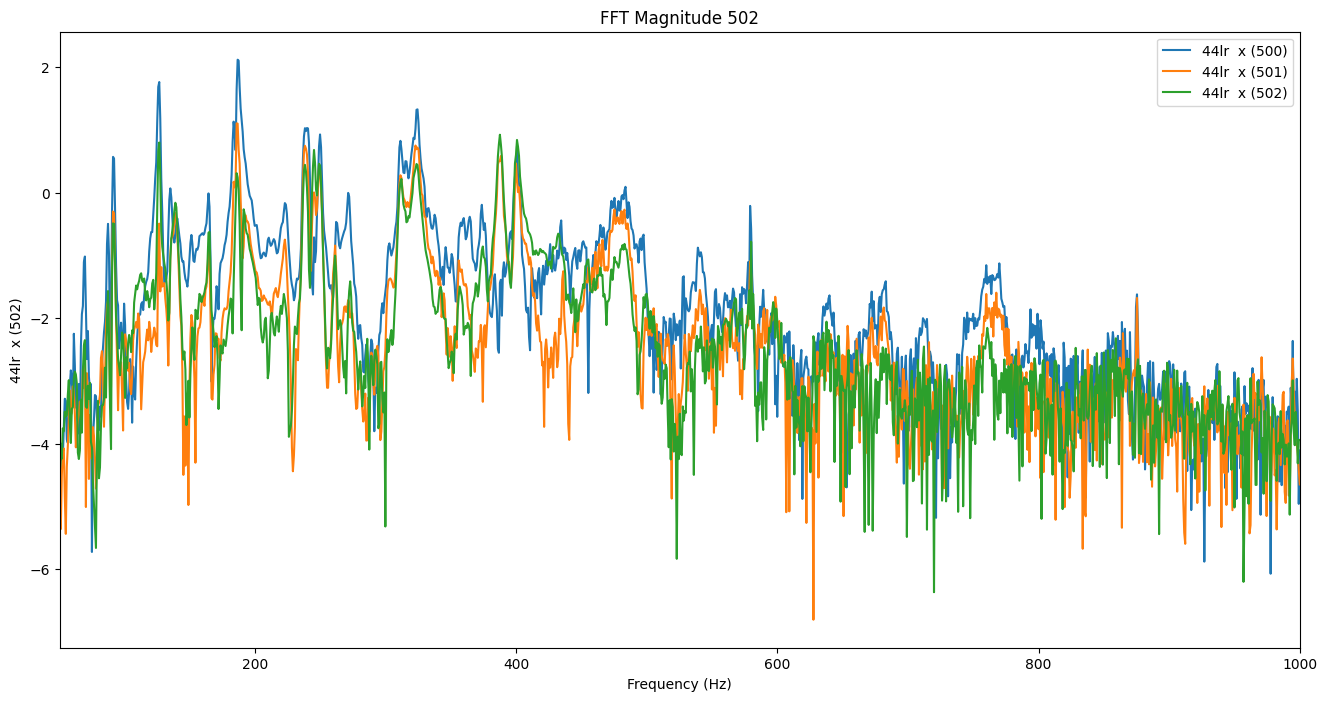

In [14]:
fig, ax = plt.subplots(figsize=(16, 8))

for sample_id in [500, 501, 502]:
    fft, freqs, sample_id = load_fft(df, sample_id)
    plot_mag(fft, freqs, sample_id, xy_idx=0, laser_idx=44, ax=ax)

# 4 Magnitude normalization grid

14 recipes: `{|FFT|, log|FFT|}` x `{none, /SM, -SM, /EB, -EB, /both, -both}`,
where `EB` is the empty-box reference and `SM` the speaker mean.

In the log domain the two references combine by `+`, in linear by `*`, since
`log(ab) = log a + log b`. Division and subtraction are the *same* operation once
you switch domains, so the matched pairs (`/` in linear, `-` in log) are the
physically motivated ones and the mismatched pairs are the control.

Everything runs on one speaker, which holds the speaker transfer function fixed.

In [15]:
SPEAKER, TOP_FRAC, LOG_EPS = 3, 0.10, 1e-3

def mags(sample_ids, mask=None, log=False):
    """|FFT| or log|FFT| for each sample, stacked. (N, L, F, C)"""
    out = []
    for s in sample_ids:
        fft, _, _ = load_fft(df, s)
        x = np.abs(fft) if mask is None else np.abs(fft)[:, mask, :]
        out.append(np.log(x + LOG_EPS) if log else x)
    return np.stack(out)

def ids(layout, speaker=None):
    m = df['layout'] == layout
    if speaker is not None: m &= df['speaker'] == speaker
    return df[m]['sample_id'].tolist()

def coms(sample_ids):
    return np.array([df[df['sample_id'] == s]['coms'].iloc[0][0][0] for s in sample_ids], float)

cube = ids('purple-cube', SPEAKER)
empty = ids('empty-box', SPEAKER)          # per-speaker; use ids('empty-box') for one global ref

fft0, freqs0, _ = load_fft(df, cube[0])
MASK = np.abs(fft0).mean((0, 2)) >= np.quantile(np.abs(fft0).mean((0, 2)), 1 - TOP_FRAC)

X = {log: mags(cube, MASK, log) for log in (0, 1)}          # samples
EB = {log: mags(empty, MASK, log).mean(0) for log in (0, 1)}  # empty-box ref
SM = {log: X[log].mean(0) for log in (0, 1)}                  # speaker mean

print(f'speaker {SPEAKER}: {len(cube)} cube, {len(empty)} empty-box, {MASK.sum()}/{len(MASK)} bins')

speaker 3: 70 cube, 4 empty-box, 124/1235 bins


In [16]:
div = lambda x, r: x / np.where(np.abs(r) < 1e-6, 1e-6, r)   # log refs cross zero
sub = lambda x, r: x - r

def build(log):
    """{name: (N, L, F, C)} for one domain.

    The combined reference pairs with the operation: '/' undoes a product, '-'
    undoes a sum. Mismatching them is the control arm.
    """
    x, eb, sm = X[log], EB[log], SM[log]
    d = 'log|FFT|' if log else '|FFT|'
    out = {d: x}
    for rname, r in [('SM', sm), ('EB', eb)]:
        out[f'{d} / {rname}'] = div(x, r)
        out[f'{d} - {rname}'] = sub(x, r)
    out[f'{d} / (EB*SM)'] = div(x, eb * sm)
    out[f'{d} - (EB+SM)'] = sub(x, eb + sm)
    return out

P = {**build(0), **build(1)}     # 14 recipes -> processed samples

print(f'{len(P)} recipes:')
for name in P: print(name)

14 recipes:
|FFT|
|FFT| / SM
|FFT| - SM
|FFT| / EB
|FFT| - EB
|FFT| / (EB*SM)
|FFT| - (EB+SM)
log|FFT|
log|FFT| / SM
log|FFT| - SM
log|FFT| / EB
log|FFT| - EB
log|FFT| / (EB*SM)
log|FFT| - (EB+SM)


/tmp/ipykernel_752951/632851185.py:92: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  if label is not None: ax.legend()


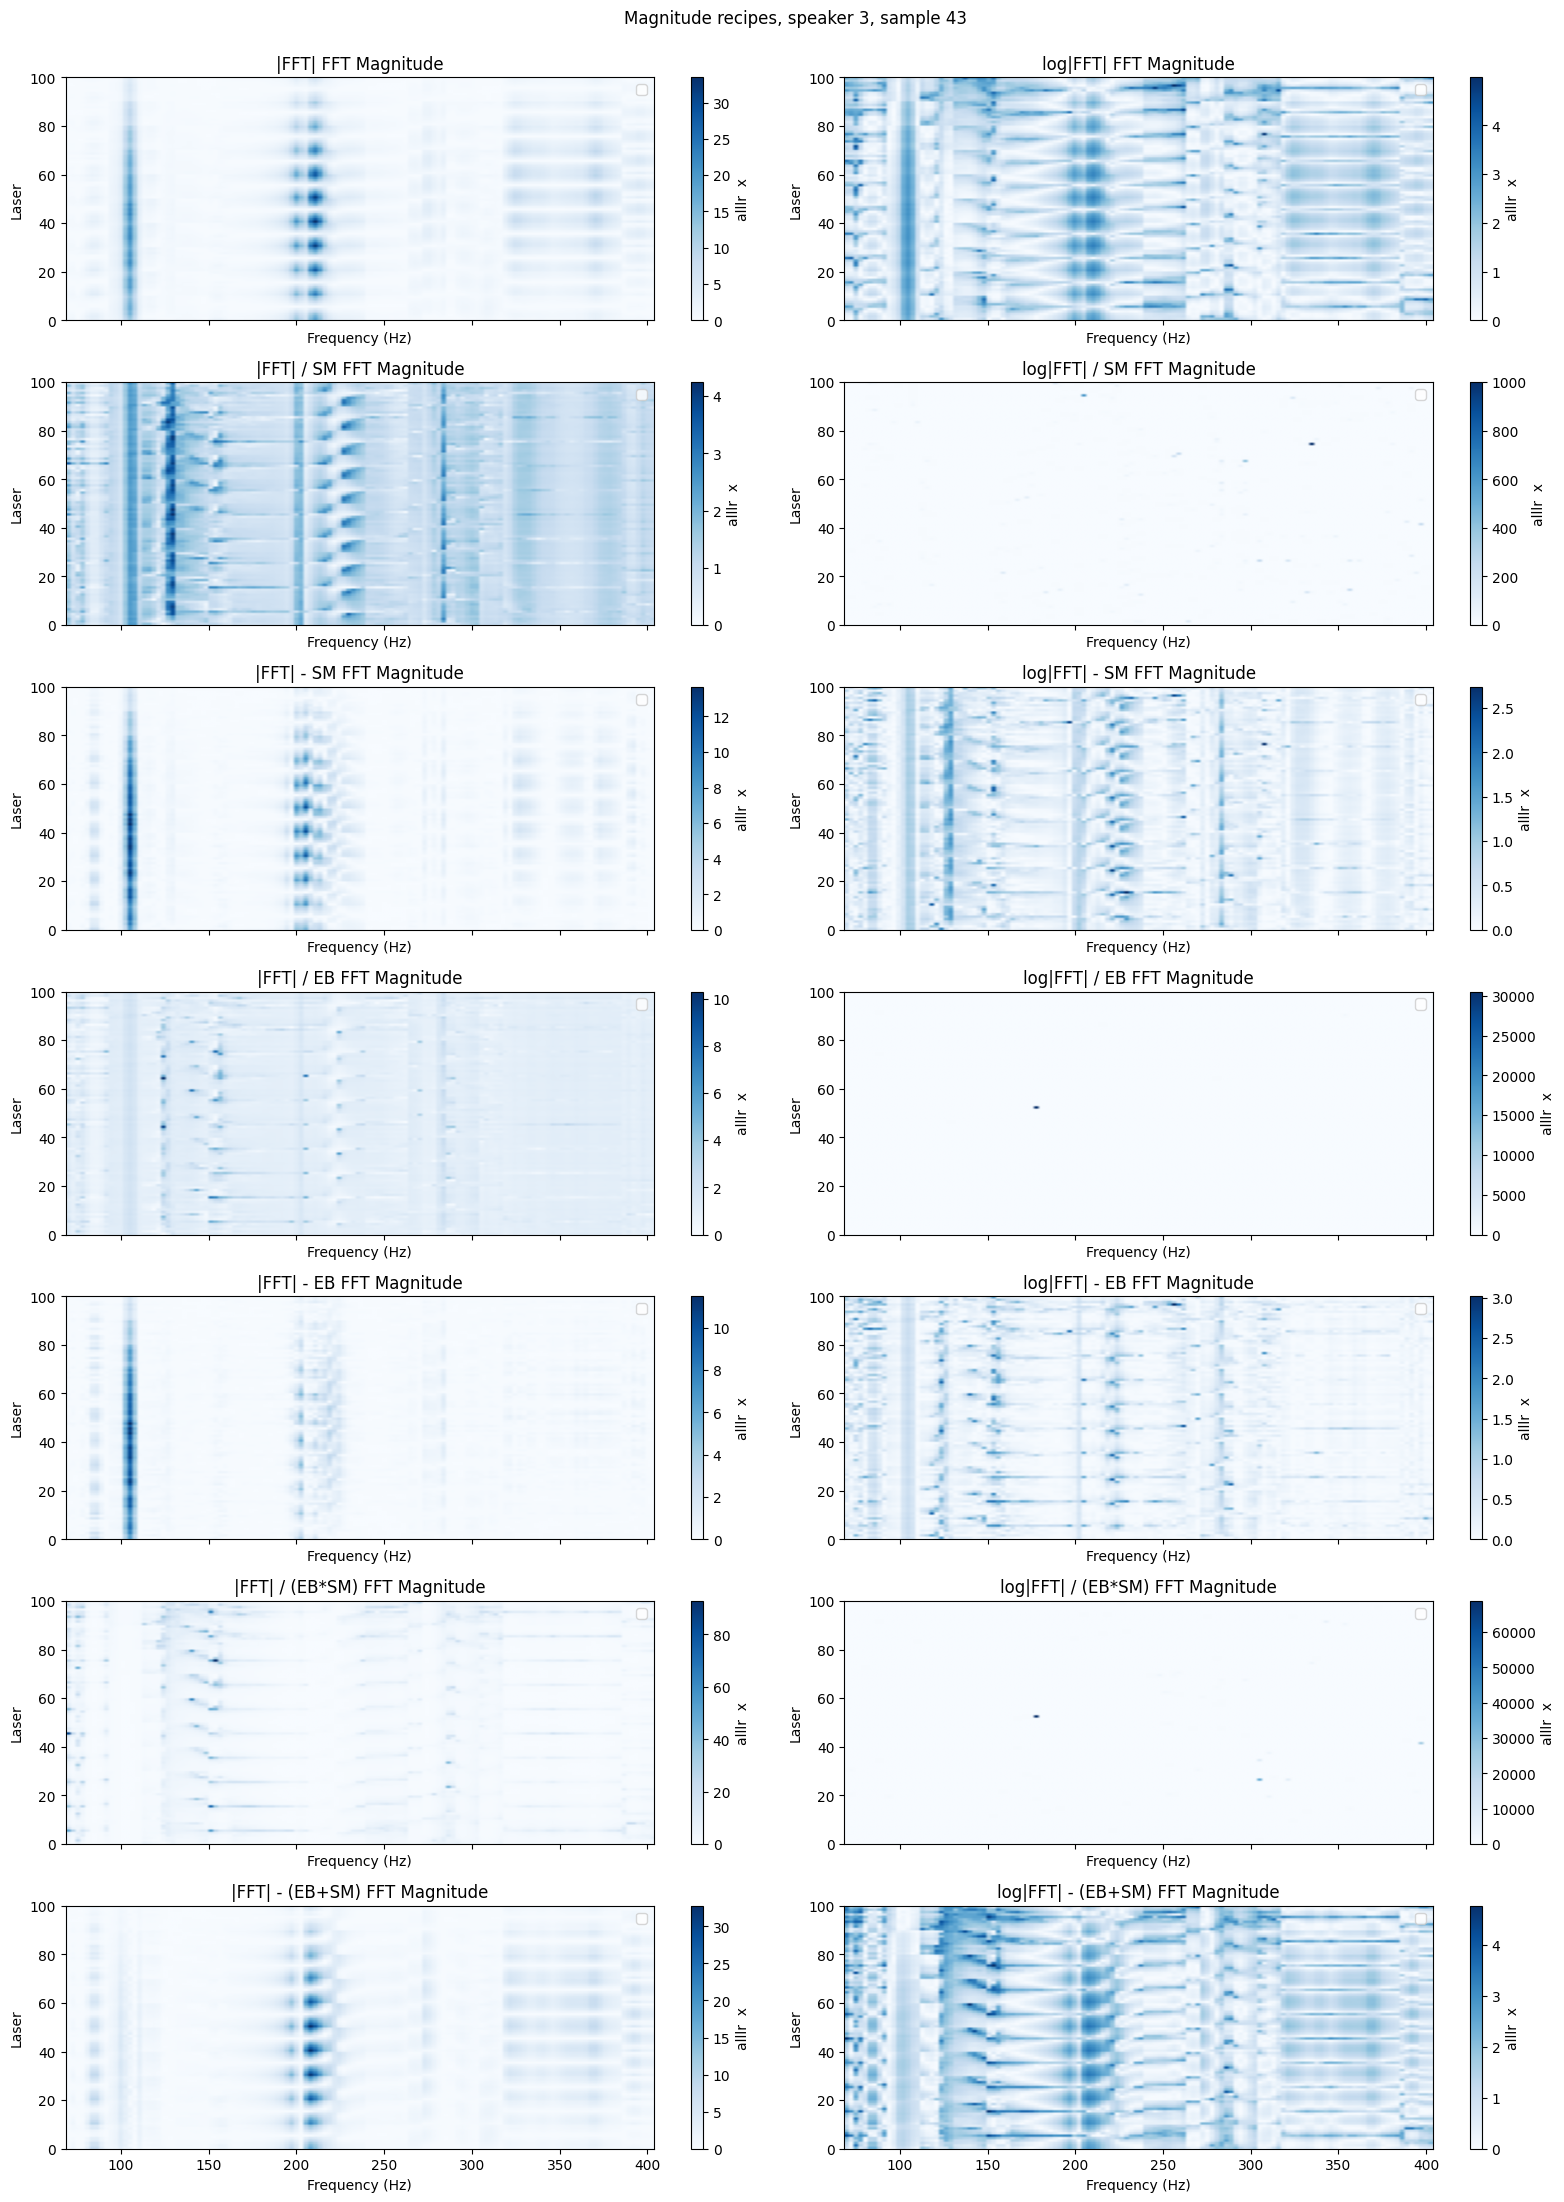

In [17]:
fb = freqs0[MASK]

# left column = |FFT| recipes, right column = their log counterparts
lin = [n for n in P if not n.startswith('log')]
names = [n for l in lin for n in (l, 'log' + l)]

fig, axs = plt.subplots(7, 2, figsize=(16, 22), sharex=True)
for ax, name in zip(axs.ravel(), names):
    plot_mag(P[name][0], fb, laser_idx='all', xy_idx=0, ax=ax, log=False, title=name)

fig.suptitle(f'Magnitude recipes, speaker {SPEAKER}, sample {cube[0]}', y=0.999)
fig.tight_layout()

In [18]:
from scipy.stats import spearmanr, pearsonr

def pairs(v, C):
    """(com_distance, cosine_similarity) for all N*(N-1)/2 sample pairs."""
    F = np.nan_to_num(v.reshape(len(v), -1).astype(np.float64), posinf=0, neginf=0)
    F -= F.mean(1, keepdims=True)
    F /= np.linalg.norm(F, axis=1, keepdims=True) + 1e-30
    iu = np.triu_indices(len(F), 1)
    return np.linalg.norm(C[:, None] - C[None, :], axis=-1)[iu], (F @ F.T)[iu]

def rho(v, C):
    """Spearman between feature similarity and COM distance.
    More negative = similarity falls off faster with distance = better."""
    return spearmanr(*pairs(v, C)).statistic

C = coms(cube)
scores = {name: rho(v, C) for name, v in P.items()}

for name, r in sorted(scores.items(), key=lambda kv: kv[1]):
    print(f'{name:>20} {r:+.4f}')

       log|FFT| - EB -0.4517
          |FFT| / EB -0.4380
  log|FFT| - (EB+SM) -0.4204
            log|FFT| -0.4169
          |FFT| / SM -0.4062
       log|FFT| - SM -0.3934
     |FFT| / (EB*SM) -0.3696
          |FFT| - EB -0.3676
       log|FFT| / SM -0.3262
               |FFT| -0.3080
     |FFT| - (EB+SM) -0.2053
          |FFT| - SM -0.1899
       log|FFT| / EB -0.1609
  log|FFT| / (EB*SM) -0.1323


In [19]:
def score(recipes, C):
    """One row per recipe. Fit a line to (com_distance, similarity), then summarise it.

    drop  = fit(nearest) - fit(farthest), i.e. how much similarity the line loses
            across the whole box. This is the RANGE the feature actually uses.
    resid = std of the points about that line. This is the NOISE.
    snr   = drop / resid. Tracks rho closely, and is the thing that ranks correctly.
    """
    rows = []
    for name, v in recipes.items():
        d, s = pairs(v, C)
        fit = np.poly1d(np.polyfit(d, s, 1))
        x = np.array([d.min(), d.max()])
        rows.append(dict(
            recipe=name,
            domain='log' if name.startswith('log') else 'lin',
            ref='EB+SM' if ('EB' in name and 'SM' in name) else
                'EB' if 'EB' in name else 'SM' if 'SM' in name else 'none',
            op='/' if '/' in name else '-' if '-' in name else 'none',
            r=pearsonr(d, s).statistic,
            rho=spearmanr(d, s).statistic,
            drop=fit(x[0]) - fit(x[1]),
            resid=(s - fit(d)).std(),
            mean_s=s.mean(),
        ))
    out = pd.DataFrame(rows)
    out['snr'] = out['drop'] / out['resid']
    return out.sort_values('snr', ascending=False).reset_index(drop=True)

res = score(P, C)
res

,recipe,domain,ref,op,r,rho,drop,resid,mean_s,snr
0,log|FFT| - EB,log,EB,-,-0.439538,-0.451667,0.361583,0.156933,0.528357,2.304054
1,|FFT| / EB,lin,EB,/,-0.435185,-0.437972,0.316764,0.139184,0.608054,2.275872
2,log|FFT| - (EB+SM),log,EB+SM,-,-0.406964,-0.420379,0.035405,0.016878,0.942537,2.097750
3,log|FFT|,log,none,none,-0.406435,-0.416944,0.039468,0.018844,0.941015,2.094486
4,|FFT| / SM,lin,SM,/,-0.403836,-0.406202,0.364176,0.175213,-0.009039,2.078475
5,log|FFT| - SM,log,SM,-,-0.391211,-0.393417,0.316716,0.158237,-0.011974,2.001529
6,|FFT| / (EB*SM),lin,EB+SM,/,-0.376184,-0.369634,0.084853,0.044387,0.760452,1.911674
7,|FFT| - EB,lin,EB,-,-0.339643,-0.367635,0.395203,0.232435,0.606532,1.700275
8,log|FFT| / SM,log,SM,/,-0.304128,-0.326194,0.533218,0.354726,-0.007823,1.503185
9,|FFT|,lin,none,none,-0.249673,-0.307999,0.031368,0.025838,0.960562,1.214027


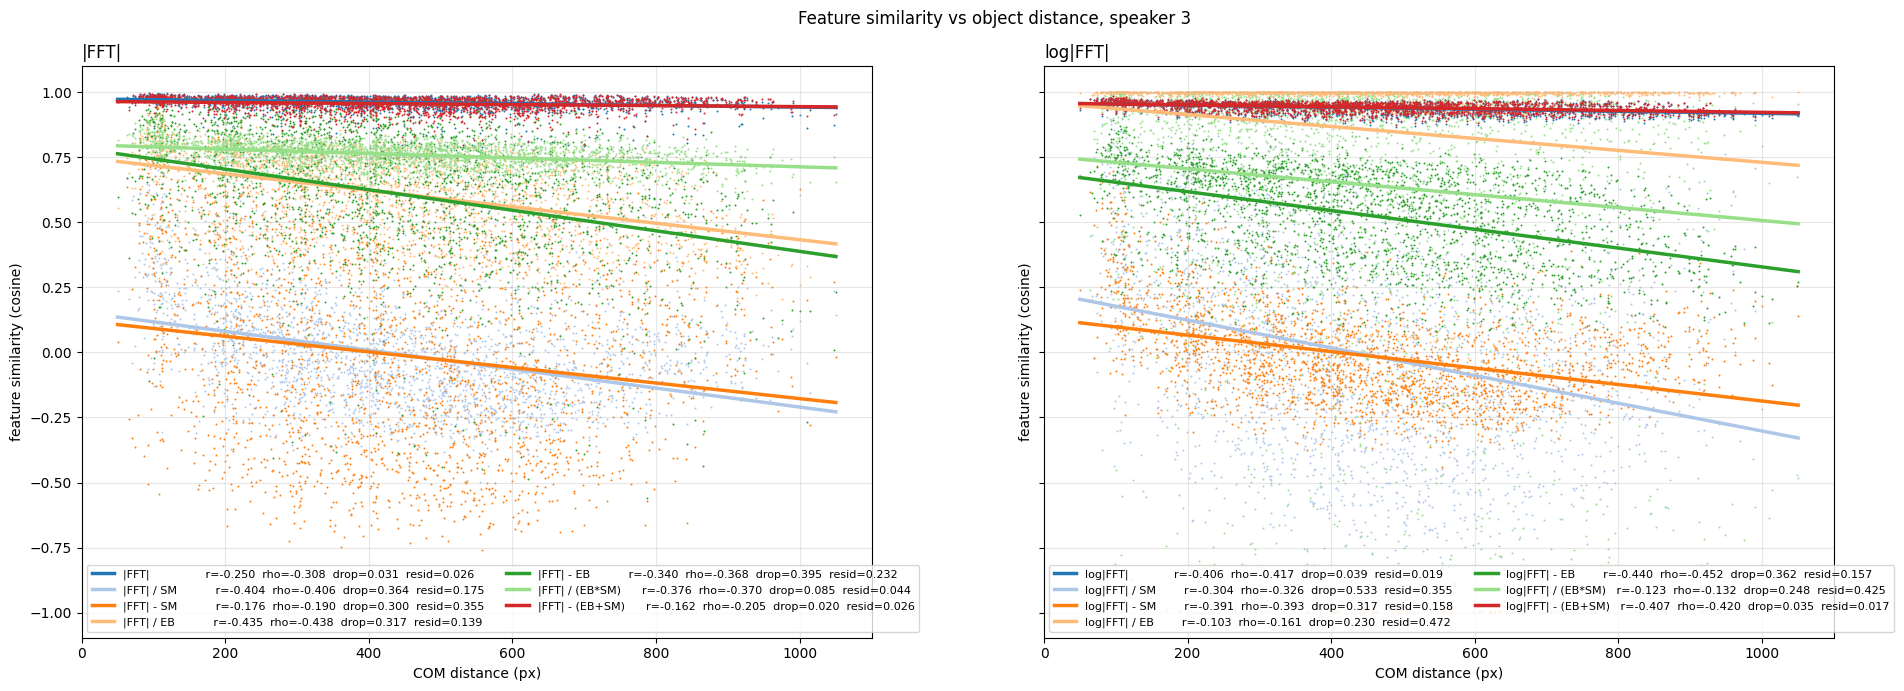

In [20]:
def plot_corr(recipes, C, ax=None, scatter=True):
    """COM distance vs feature similarity, one colour + best-fit line per recipe.

    drop  = how far the fitted line falls across the full x-range -> range used
    resid = scatter about that line                               -> noise
    Want drop large and resid small: drop/resid is the signal-to-noise of the trend.
    """
    if ax is None: fig, ax = plt.subplots(figsize=(14, 8))
    for (name, v), c in zip(recipes.items(), plt.cm.tab20.colors):
        d, s = pairs(v, C)
        fit = np.poly1d(np.polyfit(d, s, 1))
        x = np.array([d.min(), d.max()])
        drop, resid = fit(x[0]) - fit(x[1]), (s - fit(d)).std()
        if scatter: ax.scatter(d, s, s=2, alpha=1, color=c, linewidths=0)
        label = (f'{name:<20} r={pearsonr(d, s).statistic:+.3f}  '
                 f'rho={spearmanr(d, s).statistic:+.3f}  '
                 f'drop={drop:.3f}  resid={resid:.3f}')
        ax.plot(x, fit(x), color=c, lw=2.5, label=label)
    ax.set_xlabel('COM distance (px)')
    ax.set_ylabel('feature similarity (cosine)')
    ax.legend(fontsize=8, ncol=2, loc='lower left')
    ax.grid(alpha=.3)

# all 14 at once is muddy -- one panel per domain reads much better
fig, axs = plt.subplots(1, 2, figsize=(20, 7), sharey=True)
for ax, log in zip(axs, (0, 1)):
    plot_corr({n: v for n, v in P.items() if n.startswith('log') == log}, C, ax)
    ax.set_title(['|FFT|', 'log|FFT|'][log], loc='left')
fig.suptitle(f'Feature similarity vs object distance, speaker {SPEAKER}')
fig.tight_layout()

Pearson correlation (r) measures the linear relationship based on raw numerical values. Tells us how much our points fall on a straight line.

Spearman correlation (rho) measures monotonicity based on rank-ordered values. Tells us how much Y increases as X increases.

Our ideal line should have negative slope: as COM distance increases, similarity decreases. Two cubes in the same spot excite the same modes with similar |FFT|. However, this ignores that different positions in the box can have the same FFT, maybe there is an element of symmetry.

If the line is flat at large distances: we cannot differentiate between 1m and 2m.
If the line is flat at small distnace: we cannot tell 1cm from 1.1cm away.

*Drop*: Our ideal line should also have range, a large vertical drop. This means our signal genuinely changes as we move in the box. `drop = fit(nearest) − fit(farthest)`. How much similarity the fitted line loses across the whole box. It's the range the feature actually uses. The greater the better.

*Resid*: `resid = std of points about that line`. How much scatter isn't explained by distance. It's the noise. The lower the better.






Pareto-optimal (not beaten on both axes):
            recipe     drop    resid      snr       rho
log|FFT| - (EB+SM) 0.035405 0.016878 2.097750 -0.420379
          log|FFT| 0.039468 0.018844 2.094486 -0.416944
   |FFT| / (EB*SM) 0.084853 0.044387 1.911674 -0.369634
        |FFT| / EB 0.316764 0.139184 2.275872 -0.437972
     log|FFT| - EB 0.361583 0.156933 2.304054 -0.451667
        |FFT| / SM 0.364176 0.175213 2.078475 -0.406202
        |FFT| - EB 0.395203 0.232435 1.700275 -0.367635
     log|FFT| / SM 0.533218 0.354726 1.503185 -0.326194


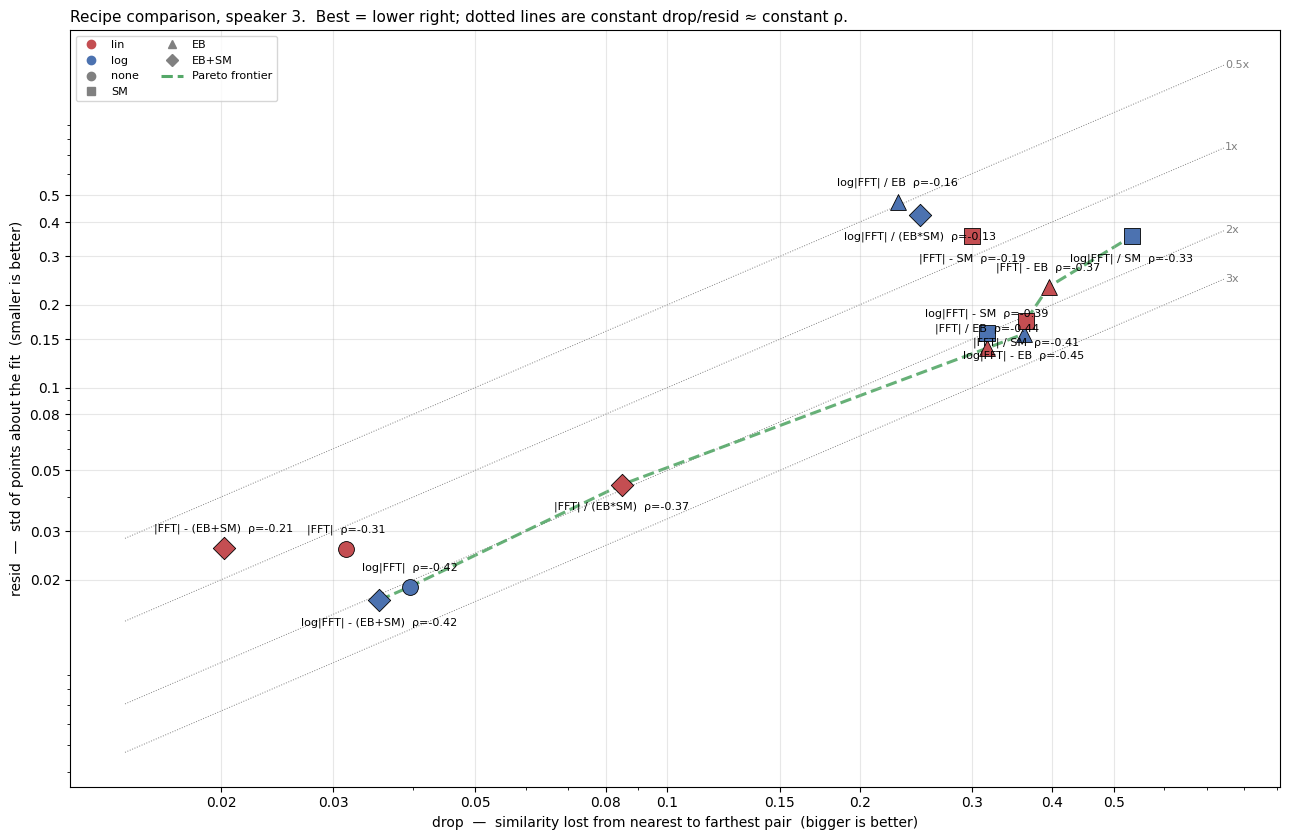

In [21]:
from matplotlib.ticker import FixedLocator, NullFormatter, FuncFormatter

MARKERS = {'none': 'o', 'SM': 's', 'EB': '^', 'EB+SM': 'D'}
COLORS = {'lin': '#C44E52', 'log': '#4C72B0'}
TICKS = [.02, .03, .05, .08, .1, .15, .2, .3, .4, .5]

def pareto(df):
    """Recipes not beaten on BOTH axes: no other has more drop AND less resid."""
    keep = [not ((df['drop'] >= r['drop']) & (df['resid'] <= r['resid']) &
                 (df.index != i)).any() for i, r in df.iterrows()]
    return df[keep].sort_values('drop')

fig, ax = plt.subplots(figsize=(13, 8.5))

xs = np.array([res['drop'].min() * .7, res['drop'].max() * 1.4])
for k in (0.5, 1, 2, 3):                      # constant drop/resid == constant rho
    ax.plot(xs, xs / k, color='gray', lw=.7, ls=':', zorder=0)
    ax.annotate(f'{k}x', (xs[1], xs[1] / k), color='gray', fontsize=8, va='center')

front = pareto(res)
ax.plot(front['drop'], front['resid'], color='#55A868', lw=2.2, ls='--', alpha=.9, zorder=1)

for i, (_, r) in enumerate(res.iterrows()):
    ax.scatter(r['drop'], r['resid'], s=130, color=COLORS[r['domain']],
               marker=MARKERS[r['ref']], edgecolors='k', linewidths=.6, zorder=3)
    ax.annotate(f"{r['recipe']}  ρ={r['rho']:+.2f}", (r['drop'], r['resid']),
                xytext=(0, 12 if i % 2 else -18), textcoords='offset points',
                fontsize=8, ha='center', zorder=4)

ax.set(xscale='log', yscale='log')
for axis in (ax.xaxis, ax.yaxis):
    axis.set_major_locator(FixedLocator(TICKS))
    axis.set_major_formatter(FuncFormatter(lambda v, _: f'{v:g}'))
    axis.set_minor_formatter(NullFormatter())

ax.set_xlabel('drop  —  similarity lost from nearest to farthest pair  (bigger is better)')
ax.set_ylabel('resid  —  std of points about the fit  (smaller is better)')
ax.set_title(f'Recipe comparison, speaker {SPEAKER}.  Best = lower right; dotted lines are constant drop/resid ≈ constant ρ.',
             loc='left', fontsize=11)
ax.grid(alpha=.3, which='major')

handles = ([plt.Line2D([], [], ls='', marker='o', color=c, label=d) for d, c in COLORS.items()]
           + [plt.Line2D([], [], ls='', marker=m, color='gray', label=k) for k, m in MARKERS.items()]
           + [plt.Line2D([], [], color='#55A868', ls='--', lw=2.2, label='Pareto frontier')])
ax.legend(handles=handles, fontsize=8, loc='upper left', ncol=2)
fig.tight_layout()

print('Pareto-optimal (not beaten on both axes):')
print(front[['recipe', 'drop', 'resid', 'snr', 'rho']].to_string(index=False))

We plot gray lines of drop/resid, which is our signal to noise ratio. drop is the signal, resid is the noise.

Even though this is linear, which is flawed, it is flawed for all the different recipies we are comparing. So maybe it is okay.

# 5 Is the box symmetric?

`resid` assumes every pair at the same distance should look equally similar. But
the box has mode shapes with nodal lines, so two cubes at **mirror-image**
positions could excite nearly the same modes and give nearly the same spectrum —
while sitting far apart in pixels.

Those pairs are far but similar. The fit charges them to `resid` as if they were
noise; really they are physics.

**The test.** Take the pairs that are far apart yet unusually similar, and draw a
segment between the two positions. If symmetry is real the segments line up — they
cross a common axis, or reflect through the box centre. If it is just noise, they
point every which way.

image   : 1337 wide x 1110 tall  -> landscape
col (x) : 230 - 1142 px   <- the wide axis
row (y) : 214 - 830 px


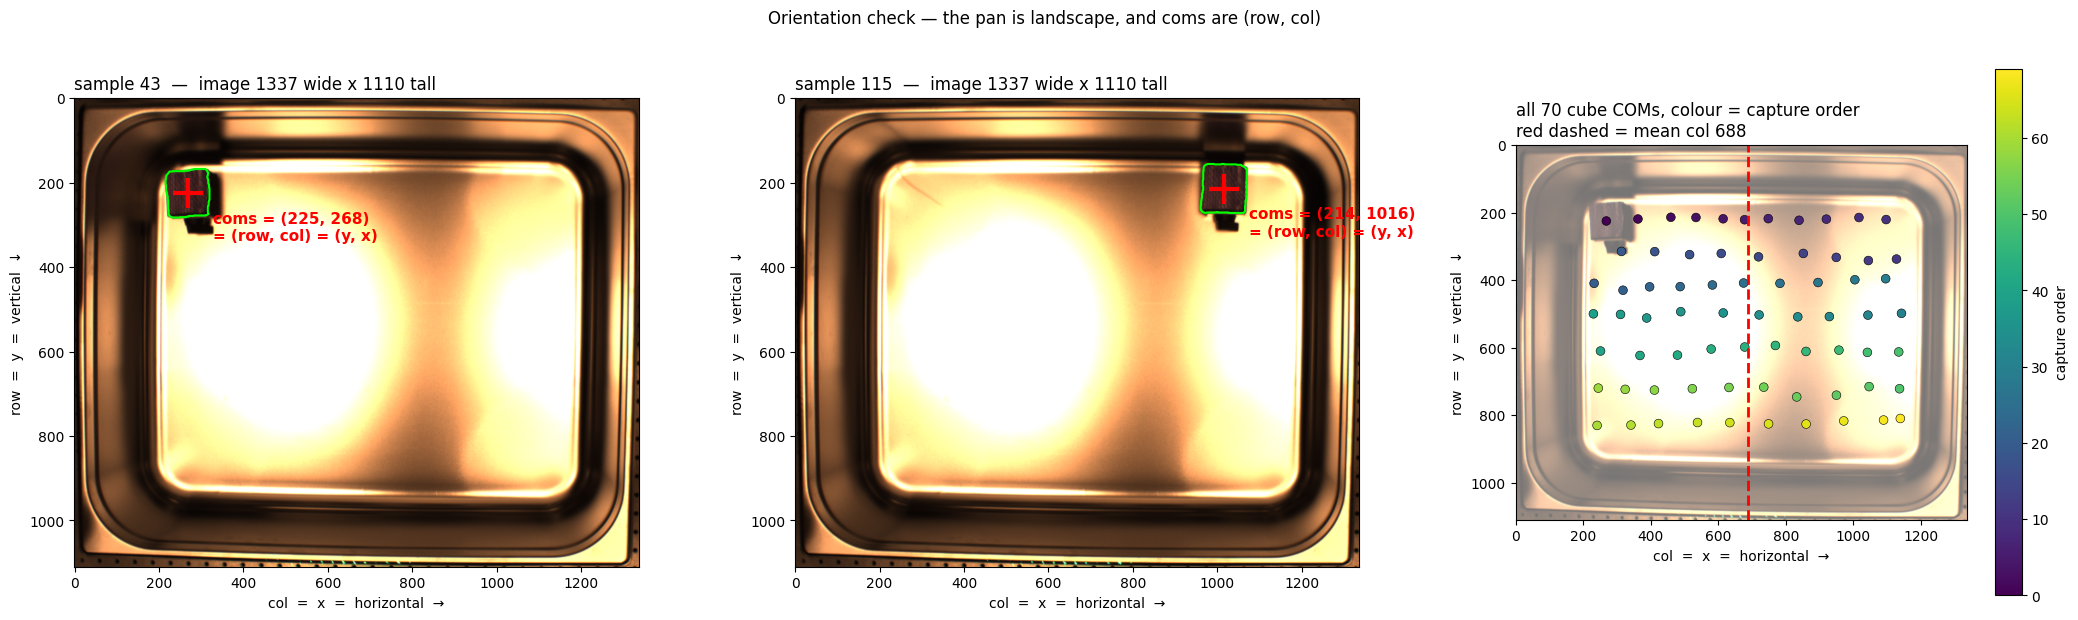

In [22]:
import PIL.Image as PILImage

# Before trusting any row/col claim, look at the actual image.
#   coms are (row, col) = (y, x) = (vertical, horizontal)
# The red cross below lands on the segmented cube, which proves the ordering.
ROW, COL = 0, 1

def overhead(sample_id):
    d = df[df['sample_id'] == sample_id]['sample_dir'].iloc[0]
    return np.array(PILImage.open(d / 'image/02_cropped_overhead.png')), np.load(d / 'image/03_smask.npy')

def label_rowcol(ax):
    ax.set_xlabel('col  =  x  =  horizontal  →')
    ax.set_ylabel('row  =  y  =  vertical  ↓')

fig, axs = plt.subplots(1, 3, figsize=(21, 6))

# two samples at the same row, different col -> shows which index slides sideways
for ax, sid in zip(axs, [cube[0], cube[9]]):
    img, smask = overhead(sid)
    com = coms([sid])[0]                                    # (row, col)
    ax.imshow(img)
    ax.contour(smask, levels=[.5], colors='lime', linewidths=1.5)
    ax.plot(com[COL], com[ROW], 'r+', ms=22, mew=3)         # imshow wants (x, y) = (col, row)
    ax.annotate(f'coms = ({com[ROW]:.0f}, {com[COL]:.0f})\n= (row, col) = (y, x)',
                (com[COL], com[ROW]), xytext=(18, -34), textcoords='offset points',
                color='red', fontsize=11, weight='bold')
    ax.set_title(f'sample {sid}  —  image {img.shape[1]} wide x {img.shape[0]} tall', loc='left')
    label_rowcol(ax)

# every cube position, coloured by capture order -> the raster scan is visible
ax = axs[2]
img, _ = overhead(cube[0])
ax.imshow(img, alpha=.55)
sc = ax.scatter(C[:, COL], C[:, ROW], s=40, c=np.arange(len(C)), cmap='viridis',
                edgecolors='k', linewidths=.4)
ax.axvline(C[:, COL].mean(), color='r', ls='--', lw=2)
ax.set_title(f'all {len(C)} cube COMs, colour = capture order\n'
             f'red dashed = mean col {C[:, COL].mean():.0f}', loc='left')
label_rowcol(ax)
fig.colorbar(sc, ax=ax, label='capture order')

fig.suptitle('Orientation check — the pan is landscape, and coms are (row, col)', y=1.02)
fig.tight_layout()

print(f'image   : {img.shape[1]} wide x {img.shape[0]} tall  -> landscape')
print(f'col (x) : {C[:, COL].min():.0f} - {C[:, COL].max():.0f} px   <- the wide axis')
print(f'row (y) : {C[:, ROW].min():.0f} - {C[:, ROW].max():.0f} px')

row: |v_i + v_j - 2c| =    206 px   (all pairs    232)   ratio 1.1x   span 616 px
col: |v_i + v_j - 2c| =     83 px   (all pairs    325)   ratio 3.9x   span 912 px


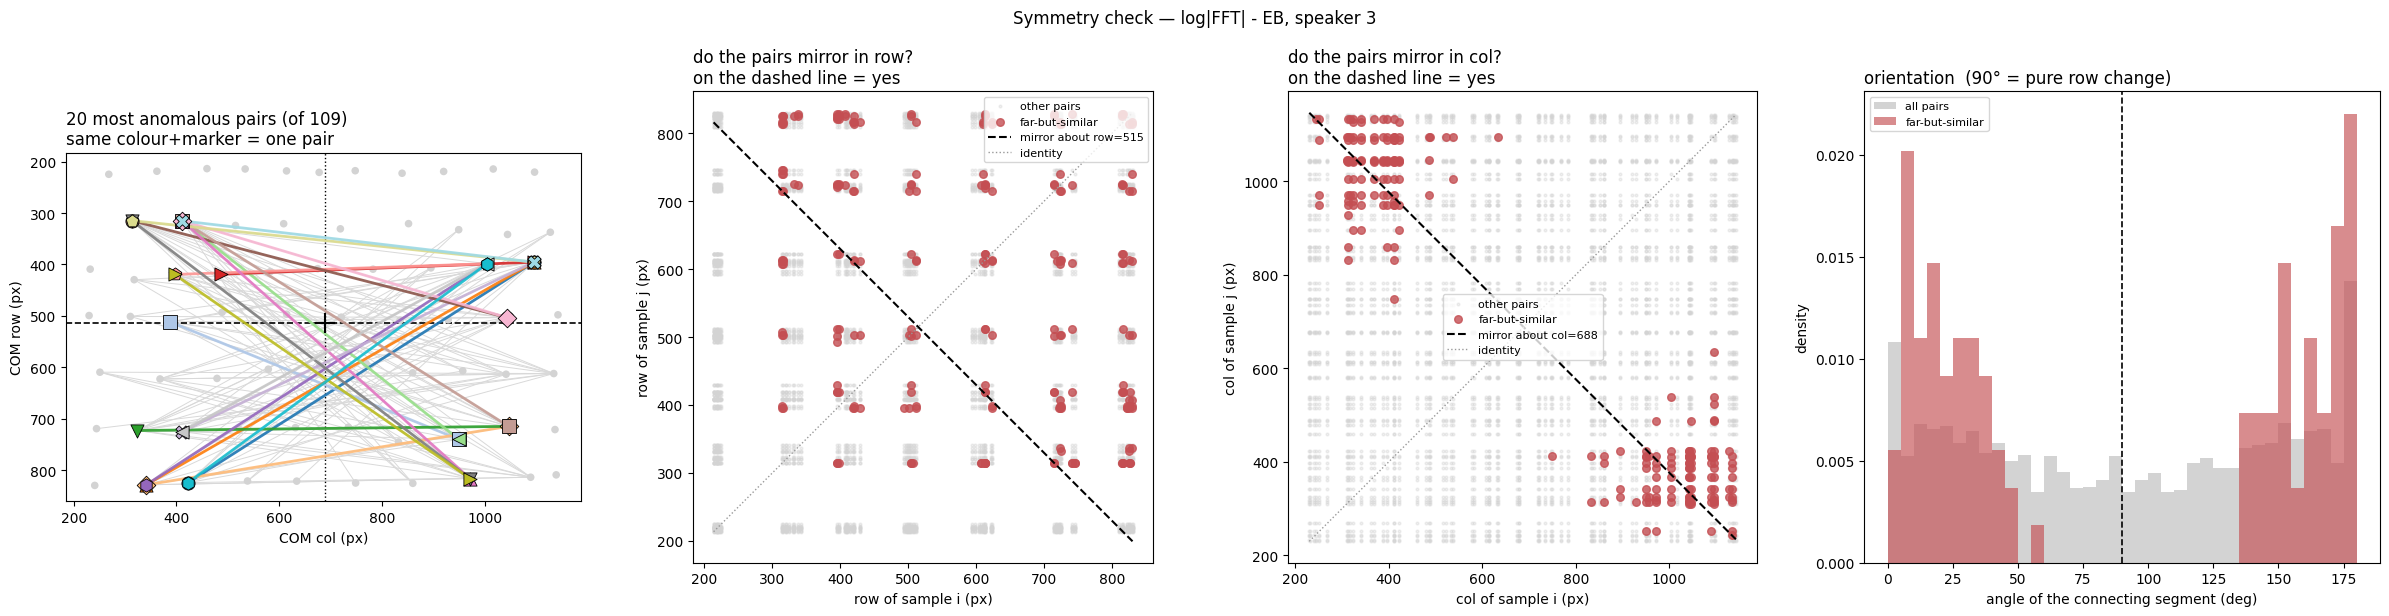

In [23]:
RECIPE = 'log|FFT| - EB'          # the winner from section 4
FAR, TOP = 600, 0.10              # "far" = >600px apart, "similar" = top 10% residual

d, s = pairs(P[RECIPE], C)
fit = np.poly1d(np.polyfit(d, s, 1))
resid = s - fit(d)                                  # + = MORE similar than distance predicts
i, j = np.triu_indices(len(C), 1)

odd = (d > FAR) & (resid > np.quantile(resid, 1 - TOP))
mid = C.mean(0)

fig, axs = plt.subplots(1, 4, figsize=(24, 6))

# --- 1 the strongest pairs, each one its own colour --------------------------
# 109 segments is unreadable, so show the 20 most anomalous with grey context.
ax = axs[0]
top_k = 20
strong = np.argsort(np.where(odd, resid, -np.inf))[-top_k:]
ax.scatter(C[:, COL], C[:, ROW], s=30, c='lightgray', zorder=2, edgecolors='none')
for k in np.flatnonzero(odd):
    ax.plot(C[[i[k], j[k]], COL], C[[i[k], j[k]], ROW], color='0.85', lw=.7, zorder=1)
for n, k in enumerate(strong):
    c = plt.cm.tab20(n / top_k)
    ax.plot(C[[i[k], j[k]], COL], C[[i[k], j[k]], ROW], color=c, lw=2, zorder=3, alpha=.9)
    ax.scatter(C[[i[k], j[k]], COL], C[[i[k], j[k]], ROW], s=90, color=c,
               marker='os^Dv<>phX*+'[n % 10], edgecolors='k', linewidths=.6, zorder=4)
ax.axhline(mid[ROW], color='k', ls='--', lw=1.2, zorder=1)
ax.axvline(mid[COL], color='k', ls=':', lw=1, zorder=1)
ax.scatter(mid[COL], mid[ROW], marker='+', s=200, color='k', zorder=5)
ax.set_title(f'{top_k} most anomalous pairs (of {odd.sum()})\nsame colour+marker = one pair', loc='left')
ax.set_aspect('equal'); ax.invert_yaxis()
ax.set_xlabel('COM col (px)'); ax.set_ylabel('COM row (px)')

# --- 2,3 coordinate of i vs coordinate of j, one panel per axis ---------------
# A mirror about c puts every pair on  v_j = 2c - v_i  (the dashed line).
# Tight on that line = that axis is mirrored. Scattered = that axis is free.
for ax, axis, name in [(axs[1], ROW, 'row'), (axs[2], COL, 'col')]:
    # plot BOTH orderings of each pair: triu_indices gives only i<j, and the capture
    # was a raster scan, so row is 92% sorted by sample index while col is 52%. That
    # bias is cosmetic (the mirror test uses v_i+v_j, which is swap-invariant) but it
    # makes one panel look triangular. Mirroring the points removes the artifact.
    both = lambda m: (np.r_[C[i[m], axis], C[j[m], axis]], np.r_[C[j[m], axis], C[i[m], axis]])
    ax.scatter(*both(~odd), s=4, color='lightgray', alpha=.35, label='other pairs')
    ax.scatter(*both(odd), s=30, color='#C44E52', alpha=.8, label='far-but-similar')
    lim = np.array([C[:, axis].min(), C[:, axis].max()])
    ax.plot(lim, 2 * mid[axis] - lim, 'k--', lw=1.5, label=f'mirror about {name}={mid[axis]:.0f}')
    ax.plot(lim, lim, color='0.6', ls=':', lw=1, label='identity')
    ax.set_xlabel(f'{name} of sample i (px)'); ax.set_ylabel(f'{name} of sample j (px)')
    ax.set_title(f'do the pairs mirror in {name}?\non the dashed line = yes', loc='left')
    ax.set_aspect('equal'); ax.legend(fontsize=8)

# --- 4 orientation ------------------------------------------------------------
ax = axs[3]
angle = lambda v: np.degrees(np.arctan2(v[:, ROW], v[:, COL])) % 180
ax.hist(angle(C[j] - C[i]), bins=36, range=(0, 180), density=True,
        color='lightgray', label='all pairs')
ax.hist(angle(C[j[odd]] - C[i[odd]]), bins=36, range=(0, 180), density=True,
        color='#C44E52', alpha=.65, label='far-but-similar')
ax.axvline(90, color='k', ls='--', lw=1.2)
ax.set_xlabel('angle of the connecting segment (deg)'); ax.set_ylabel('density')
ax.set_title('orientation  (90° = pure row change)', loc='left')
ax.legend(fontsize=8, loc='upper left')

fig.suptitle(f'Symmetry check — {RECIPE}, speaker {SPEAKER}', y=1.02)
fig.tight_layout()

# how badly does each axis violate its mirror?  small = that axis IS mirrored
for axis, name in [(ROW, 'row'), (COL, 'col')]:
    v = np.abs(C[i[odd], axis] + C[j[odd], axis] - 2 * mid[axis])
    v_all = np.abs(C[i, axis] + C[j, axis] - 2 * mid[axis])
    span = C[:, axis].max() - C[:, axis].min()
    print(f'{name:>3}: |v_i + v_j - 2c| = {v.mean():6.0f} px   (all pairs {v_all.mean():6.0f})'
          f'   ratio {v_all.mean() / v.mean():.1f}x   span {span:.0f} px')

1. We have points in upper triangluar for rows but all over for columns because we recorded the data in a raster scan: go to a row, sweep across all columns there, then go to the next row, and across coumns, and repeat. This means that we almost always get row_i < row_j. To fix this, we plot both orderings so each panel is symmetric about the identity: ax.scatter(np.r_[C[i,axis], C[j,axis]], np.r_[C[j,axis], C[i,axis]], ...)

2. The third plot is the most important. When we have an outlier, it appears in the upper left and lower right. 
Upper-left: col_i ≈ 200–400, col_j ≈ 950–1150
Lower-right: col_i ≈ 950–1150, col_j ≈ 250–450

Both clusters are off-diagonal. In each one, sample i is at a low col and sample j at a high col (or vice versa). They are not both ~1000.

If both had col ≈ 1000, they'd sit at the top-right corner on the identity line (the dotted diagonal). That region is conspicuously empty of red.

This means that when we have differing col positions, we have similar |FFT|. In other words, we cannot differentiate between the left and right of the box that easily.

The box has a mirror symmetry about the vertical line at col ≈ 688. A cube left of center is confusable with its reflection to the right; row position doesn't disambiguate. 

## Which reflection is it?

Some confused pairs flip left<->right; some flip in *both* axes at once (a point
reflection through the box centre). Classify each one.

A pair is **mirrored in an axis** when its two coordinates sum to twice the axis
position -- the reflection of `v` about `c` is `2c - v`, so `v_i + v_j = 2c`:

```
dc = |col_i + col_j - 2*col_axis|     small  ->  mirrored left<->right
dr = |row_i + row_j - 2*row_axis|     small  ->  mirrored top<->bottom
```

Two booleans, four categories: **col only**, **row only**, **BOTH** (point
reflection), **neither**. Each count is compared against the same classification run
over *all* 2415 pairs -- that null says what each bin gets by chance from the grid
layout alone, so we read enrichment rather than raw percentages.

symmetry axis: col=688, row=515   outliers n=109, all pairs n=2415

                             BOTH               col only               row only                neither
tol  60px    5.5% vs   1.6% ( 3.4x)  36.7% vs  10.3% ( 3.6x)   8.3% vs  12.8% ( 0.6x)  49.5% vs  75.3% ( 0.7x)
tol 100px   16.5% vs   5.2% ( 3.2x)  51.4% vs  14.6% ( 3.5x)   7.3% vs  21.9% ( 0.3x)  24.8% vs  58.3% ( 0.4x)
tol 140px   34.9% vs  10.4% ( 3.4x)  47.7% vs  16.6% ( 2.9x)   9.2% vs  28.1% ( 0.3x)   8.3% vs  44.9% ( 0.2x)

format: outliers vs null (enrichment).  >1x = over-represented.


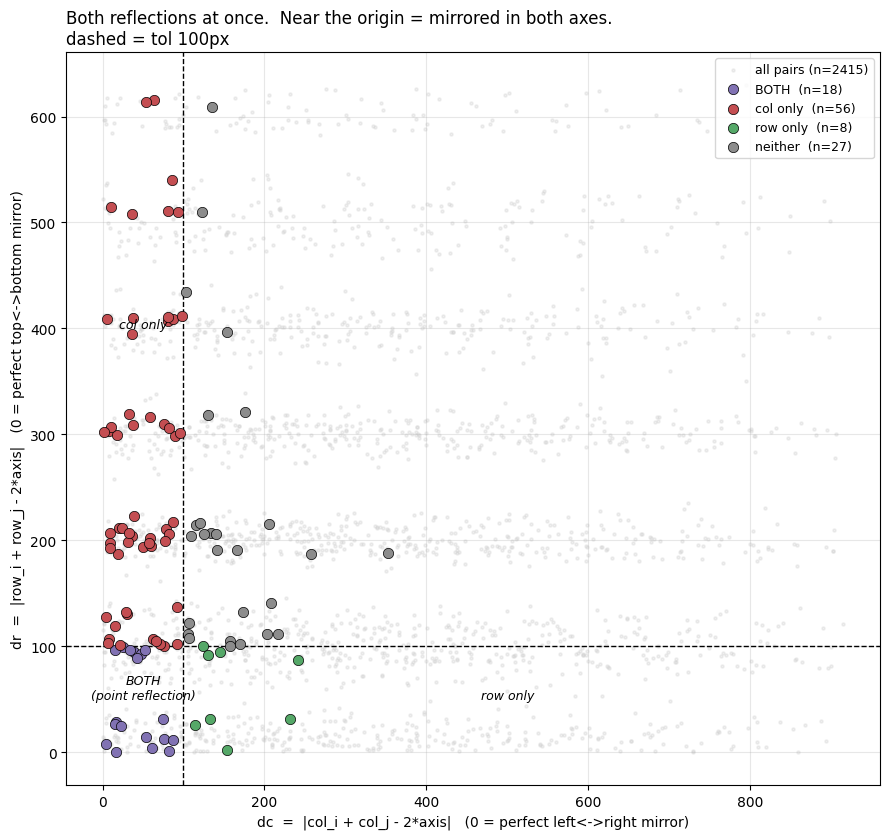

In [24]:
AXIS = C.mean(0)          # (row, col) of the symmetry centre

def mirror_err(mask):
    """How far each pair is from being mirrored, per axis. Small = mirrored."""
    dc = np.abs(C[i[mask], COL] + C[j[mask], COL] - 2 * AXIS[COL])
    dr = np.abs(C[i[mask], ROW] + C[j[mask], ROW] - 2 * AXIS[ROW])
    return dc, dr

def classify(mask, tol):
    """col only / row only / BOTH / neither, by thresholding each axis at `tol`."""
    dc, dr = mirror_err(mask)
    mc, mr = dc < tol, dr < tol                       # mirrored in col / in row
    lab = np.full(mask.sum(), 'neither', dtype=object)
    lab[mc & ~mr] = 'col only'
    lab[~mc & mr] = 'row only'
    lab[mc & mr]  = 'BOTH'
    return lab

CATS = ['BOTH', 'col only', 'row only', 'neither']
allp = np.ones(len(d), bool)

print(f'symmetry axis: col={AXIS[COL]:.0f}, row={AXIS[ROW]:.0f}   '
      f'outliers n={odd.sum()}, all pairs n={len(d)}\n')
print(f'{"":>10} ' + ' '.join(f'{c:>22}' for c in CATS))
for tol in (60, 100, 140):
    lab, null = classify(odd, tol), classify(allp, tol)
    cells = []
    for c in CATS:
        k, n = (lab == c).mean(), (null == c).mean()
        cells.append(f'{100*k:5.1f}% vs {100*n:5.1f}% ({k/max(n,1e-9):4.1f}x)')
    print(f'tol {tol:>3}px  ' + ' '.join(f'{x:>22}' for x in cells))
print('\nformat: outliers vs null (enrichment).  >1x = over-represented.')

# ---- the (dc, dr) plane: one point per pair, four regions ---------------------
TOL = 100
dc_o, dr_o = mirror_err(odd)
dc_a, dr_a = mirror_err(allp)

fig, ax = plt.subplots(figsize=(9, 8.5))
ax.scatter(dc_a, dr_a, s=5, color='lightgray', alpha=.35, label=f'all pairs (n={len(d)})')
lab = classify(odd, TOL)
for c, col in zip(CATS, ['#8172B3', '#C44E52', '#55A868', '#8C8C8C']):
    m = lab == c
    if m.any():
        ax.scatter(dc_o[m], dr_o[m], s=55, color=col, edgecolors='k', linewidths=.5,
                   label=f'{c}  (n={m.sum()})', zorder=3)
ax.axvline(TOL, color='k', ls='--', lw=1); ax.axhline(TOL, color='k', ls='--', lw=1)
ax.annotate('BOTH\n(point reflection)', (TOL * .5, TOL * .5), ha='center', fontsize=9, style='italic')
ax.annotate('col only', (TOL * .5, TOL * 4), ha='center', fontsize=9, style='italic')
ax.annotate('row only', (TOL * 5, TOL * .5), ha='center', fontsize=9, style='italic')
ax.set_xlabel('dc  =  |col_i + col_j - 2*axis|   (0 = perfect left<->right mirror)')
ax.set_ylabel('dr  =  |row_i + row_j - 2*axis|   (0 = perfect top<->bottom mirror)')
ax.set_title(f'Both reflections at once.  Near the origin = mirrored in both axes.\n'
             f'dashed = tol {TOL}px', loc='left')
ax.legend(fontsize=9); ax.grid(alpha=.3)
fig.tight_layout()


## What the three reflection types look like

One block per category. Each row is a confused pair: two positions whose spectra the
model cannot tell apart.

* **BOTH** -- point reflection: the cube flips across *both* axes at once.
* **col only** -- pure left<->right flip; row is unconstrained.
* **row only** -- pure top<->bottom flip. Depleted vs chance (0.3x), so these should
  look like coincidences rather than a real family.

`red +` is this cube. The `black |` marks where its partner's column would land if
the mirror were exact -- only the column is predicted, since that is the axis the
symmetry actually constrains.

median cosine similarity by category (all outliers have sim well above the fit):
        BOTH  n= 18   sim=0.640   dist=731px
    col only  n= 56   sim=0.671   dist=714px
    row only  n=  8   sim=0.646   dist=756px
     neither  n= 27   sim=0.658   dist=688px
    baseline  n=2306   sim=0.554   dist=417px   <- all non-outlier pairs


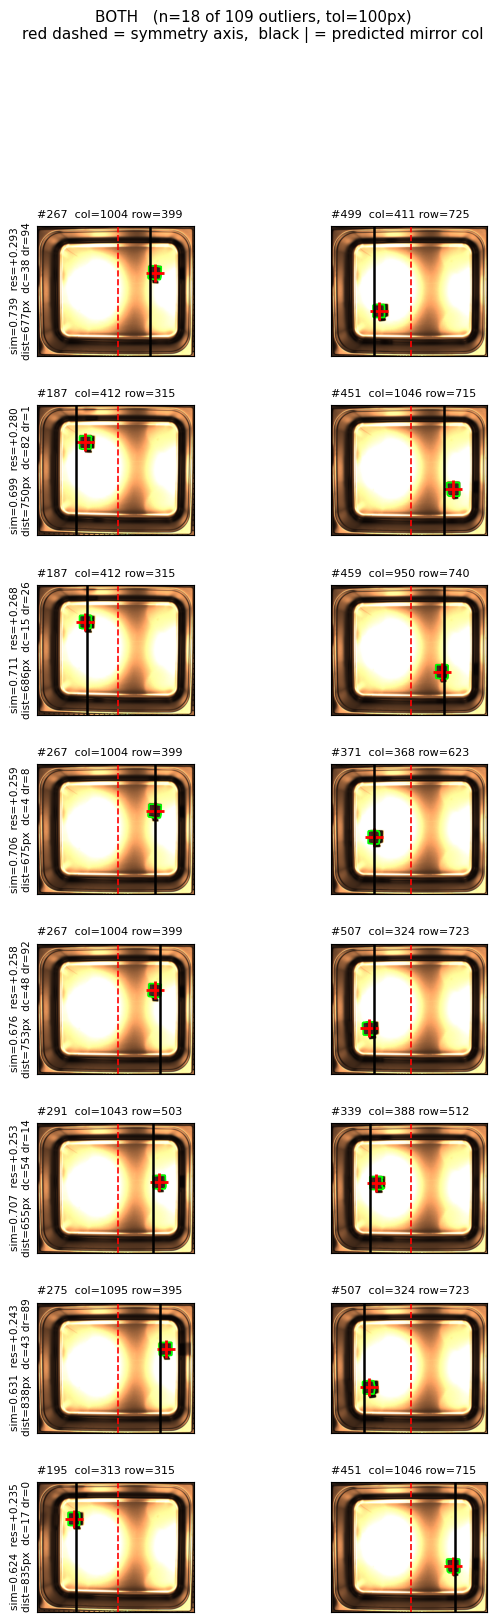

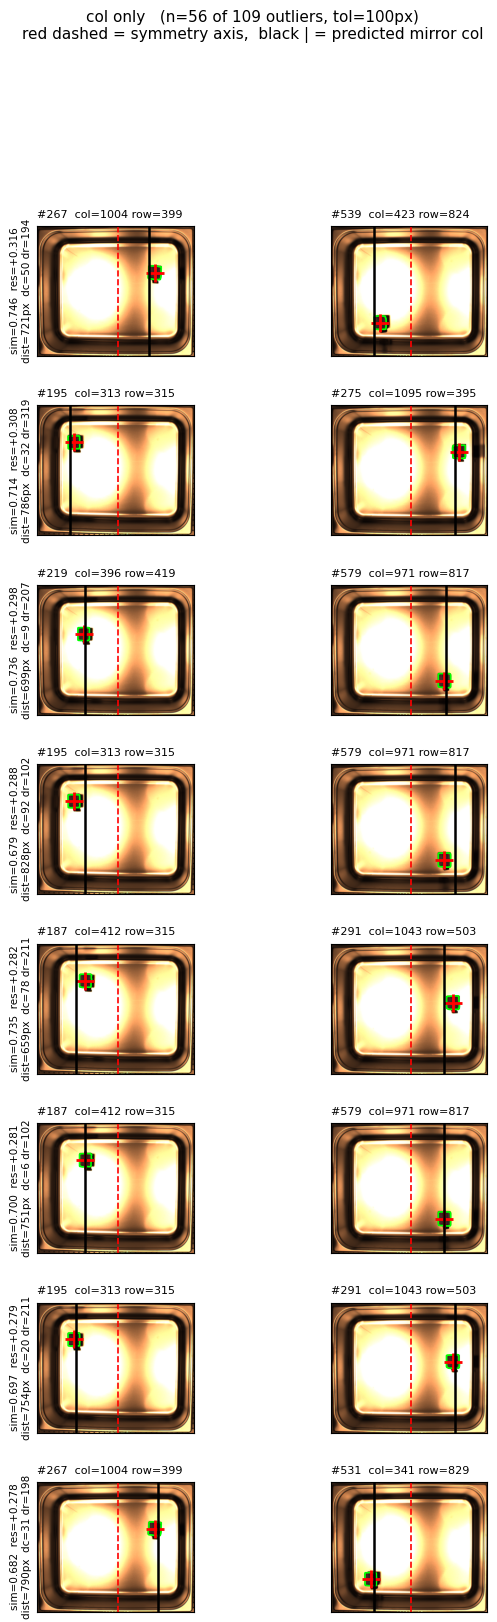

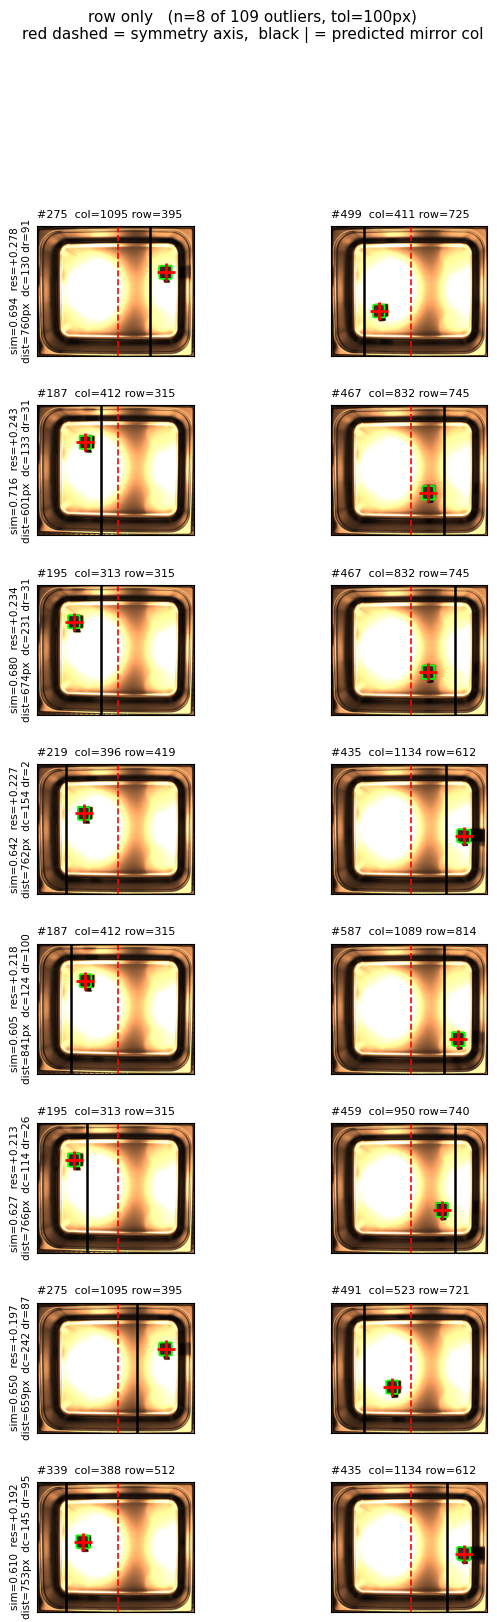

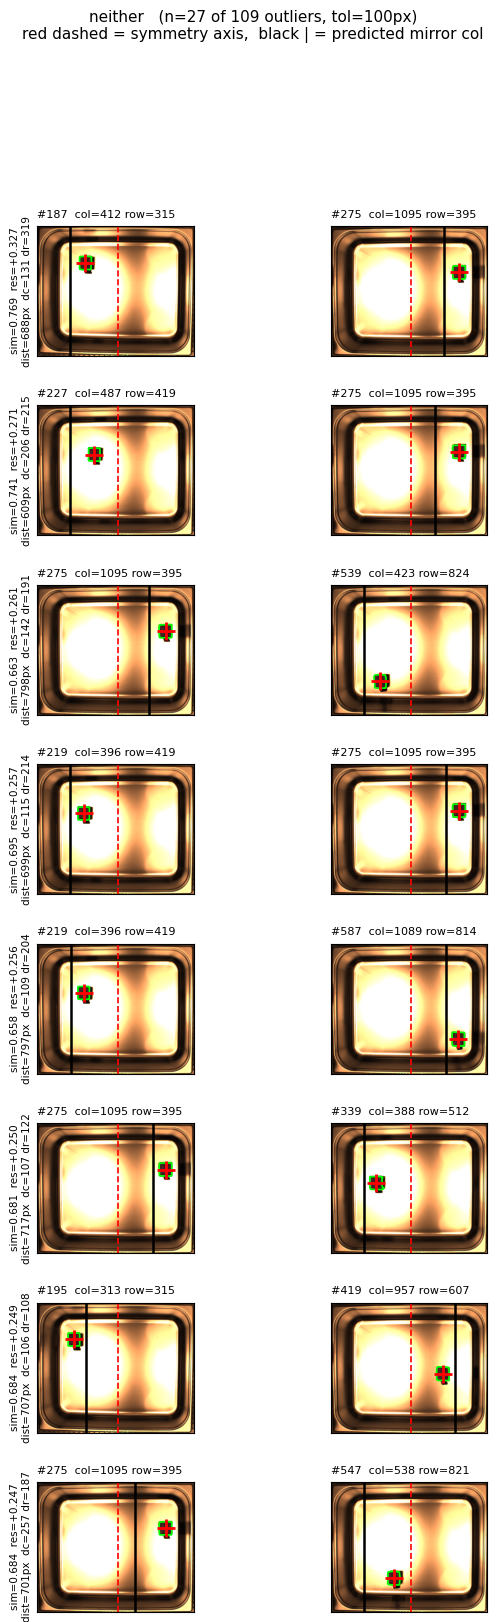

In [25]:
def show_pairs(keep, title, n_max=8):
    """Side-by-side overhead images for the strongest pairs in one category.

    Left labels, per pair:
      sim   cosine similarity of the two feature vectors  (why the pair is an outlier)
      res   how far above the fitted line that similarity sits
      dist  how far apart the two cubes are, in px
      dc/dr mirror error per axis, in px (small = mirrored in that axis)
    """
    ks = np.flatnonzero(odd)[np.argsort(-resid[odd])]          # strongest first
    ks = [k for k in ks if keep[np.flatnonzero(odd) == k][0]][:n_max]
    if not ks:
        print(f'{title}: no pairs'); return

    fig, axs = plt.subplots(len(ks), 2, figsize=(7.5, 2.25 * len(ks)),
                            gridspec_kw=dict(wspace=.02, hspace=.38), squeeze=False)
    for n, k in enumerate(ks):
        for side, sid in enumerate([cube[i[k]], cube[j[k]]]):
            ax = axs[n, side]
            img, smask = overhead(sid)
            com = coms([sid])[0]
            ax.imshow(img)
            ax.contour(smask, levels=[.5], colors='lime', linewidths=1.2)
            ax.axvline(AXIS[COL], color='r', ls='--', lw=1.2)
            ax.plot(com[COL], com[ROW], 'r+', ms=13, mew=2)
            # predicted mirror COLUMN of the partner (row is not mirrored -> no point marker)
            other = coms([cube[j[k]] if side == 0 else cube[i[k]]])[0]
            ax.axvline(2 * AXIS[COL] - other[COL], color='k', lw=1.8)
            ax.set_xticks([]); ax.set_yticks([])
            ax.set_title(f'#{sid}  col={com[COL]:.0f} row={com[ROW]:.0f}', fontsize=8, loc='left')
        one = np.isin(np.arange(len(d)), [k])
        dc, dr = mirror_err(one)
        axs[n, 0].set_ylabel(f'sim={s[k]:.3f}  res={resid[k]:+.3f}\n'
                             f'dist={d[k]:.0f}px  dc={dc[0]:.0f} dr={dr[0]:.0f}', fontsize=7.5)
    fig.suptitle(title, y=1.0, fontsize=11)

lab = classify(odd, TOL)
print(f'median cosine similarity by category (all outliers have sim well above the fit):')
for cat in CATS:
    m = lab == cat
    if m.any():
        print(f'   {cat:>9}  n={m.sum():3d}   sim={np.median(s[odd][m]):.3f}   '
              f'dist={np.median(d[odd][m]):.0f}px')
print(f'   {"baseline":>9}  n={(~odd).sum():3d}   sim={np.median(s[~odd]):.3f}   '
      f'dist={np.median(d[~odd]):.0f}px   <- all non-outlier pairs')

for cat in CATS:                       # BOTH, col only, row only, neither
    n = (lab == cat).sum()
    show_pairs(lab == cat, f'{cat}   (n={n} of {odd.sum()} outliers, tol={TOL}px)\n'
                           f'red dashed = symmetry axis,  black | = predicted mirror col')
